## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2023-May_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Timeline_2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-05-01,2023,5,2023-04-30,40.659996,22.397246,0.189948,-0.054951,-0.195018,0.054951,0.203597,-0.056477,-0.208414,0.056477,0.090037,0.067204,0.074951,0.067204,2023-05-01,40.659996,22.397246,15255.0,14332.0,40.659996,22.397246,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,2023-05-01,40.650186,22.350102,49.232035,2023-04-24,2023-04-17,2023-04-24,2023-04-17,0.494345,5.837251
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-05-16,2023,5,2023-05-15,40.659996,22.397246,0.189948,-0.054951,-0.195018,0.054951,0.203597,-0.056477,-0.208414,0.056477,0.090037,0.067204,0.074951,0.067204,2023-05-15,40.659996,22.397246,15417.0,14252.0,40.659996,22.397246,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,2023-05-16,40.650186,22.350102,130.514210,2023-05-09,2023-05-02,2023-05-09,2023-05-02,2.970342,80.412278
2,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-05-01,2023,5,2023-04-30,40.677962,22.464619,0.110222,-0.165351,-0.172650,0.165351,0.163025,-0.120348,-0.203631,0.120348,0.060902,0.038216,0.052802,0.038216,2023-05-01,40.677962,22.464619,15351.0,14260.0,40.677962,22.464619,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,2023-05-01,40.650186,22.450103,56.700632,2023-04-24,2023-04-17,2023-04-24,2023-04-17,0.504019,3.901367
3,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-05-16,2023,5,2023-05-15,40.677962,22.464619,0.110222,-0.165351,-0.172650,0.165351,0.163025,-0.120348,-0.203631,0.120348,0.060902,0.038216,0.052802,0.038216,2023-05-15,40.677962,22.464619,15192.0,14255.0,40.677962,22.464619,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,2023-05-16,40.650186,22.450103,98.651144,2023-05-09,2023-05-02,2023-05-09,2023-05-02,3.535526,41.243582
4,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-05-01,2023,5,2023-04-30,40.624063,22.491569,0.253299,-0.038819,-0.281858,0.038819,0.217262,-0.067217,-0.254128,0.067217,0.043139,0.036751,0.030546,0.036751,2023-05-01,40.624063,22.491569,15195.0,14244.0,40.624063,22.491569,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,2023-05-01,40.650186,22.450103,56.700632,2023-04-24,2023-04-17,2023-04-24,2023-04-17,0.504019,3.901367


In [6]:
#wnv_file.head()

In [7]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-05-01,2023,5,0.189948,-0.054951,-0.195018,0.054951,0.203597,-0.056477,-0.208414,0.056477,0.090037,0.067204,0.074951,0.067204,15255.0,14332.0,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,49.232035,0.494345,5.837251
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-05-16,2023,5,0.189948,-0.054951,-0.195018,0.054951,0.203597,-0.056477,-0.208414,0.056477,0.090037,0.067204,0.074951,0.067204,15417.0,14252.0,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,130.514210,2.970342,80.412278
2,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-05-01,2023,5,0.110222,-0.165351,-0.172650,0.165351,0.163025,-0.120348,-0.203631,0.120348,0.060902,0.038216,0.052802,0.038216,15351.0,14260.0,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,56.700632,0.504019,3.901367
3,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-05-16,2023,5,0.110222,-0.165351,-0.172650,0.165351,0.163025,-0.120348,-0.203631,0.120348,0.060902,0.038216,0.052802,0.038216,15192.0,14255.0,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,98.651144,3.535526,41.243582
4,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-05-01,2023,5,0.253299,-0.038819,-0.281858,0.038819,0.217262,-0.067217,-0.254128,0.067217,0.043139,0.036751,0.030546,0.036751,15195.0,14244.0,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,56.700632,0.504019,3.901367


In [11]:
#wnv_file.head(5)

In [12]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [13]:
#wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))

In [14]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [15]:
# merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [16]:
# merged

In [17]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [18]:
merged['case'].value_counts()

0    360
Name: case, dtype: int64

In [19]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [20]:
dataset = grouped.mean()

In [21]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-05-01,αλεξανδρειας,κεντρικης μακεδονιας,22.483978,40.644680,2023.0,5.0,0.170150,-0.100573,-0.212535,0.100573,0.180756,-0.089859,-0.216488,0.089859,0.056536,0.041263,0.047193,0.041263,15266.500000,14262.750000,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,54.796496,1.026141,4.464013,0.0
1,2023-05-01,αλμωπιας,κεντρικης μακεδονιας,21.940791,40.977027,2023.0,5.0,0.522353,0.123491,-0.447140,-0.123491,0.529450,0.124210,-0.459599,-0.124210,0.054125,0.054755,0.030793,0.054755,14510.727273,13972.181818,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,172.360332,7.549537,31.277387,0.0
2,2023-05-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2023.0,5.0,0.157606,0.030411,-0.169270,-0.030411,0.198656,0.031271,-0.205202,-0.031271,0.092685,0.059763,0.069722,0.059763,15051.000000,14251.000000,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,129.586469,8.539829,24.316921,0.0
3,2023-05-01,αμφιπολης,κεντρικης μακεδονιας,23.982527,40.915102,2023.0,5.0,0.301201,0.177338,-0.259019,-0.177338,0.378091,0.212700,-0.314783,-0.212700,0.060114,0.092679,0.062196,0.092679,14701.250000,14108.500000,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,73.469888,12.292893,36.676132,0.0
4,2023-05-01,αριστοτελη,κεντρικης μακεδονιας,23.691080,40.495934,2023.0,5.0,0.626137,0.251029,-0.497413,-0.251029,0.615676,0.248771,-0.488425,-0.248771,0.060201,0.055246,0.041223,0.055246,14574.250000,14108.125000,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,161.783456,13.509865,88.392827,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,2023-05-16,σιθωνιας,κεντρικης μακεδονιας,23.828106,40.110264,2023.0,5.0,0.460100,0.185161,-0.359489,-0.185161,0.458051,0.179094,-0.360377,-0.179094,0.047389,0.048060,0.026991,0.048060,14881.200000,14261.000000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,297.676055,7.359427,52.826785,0.0
72,2023-05-16,σιντικης,κεντρικης μακεδονιας,23.388058,41.313484,2023.0,5.0,0.518181,0.131836,-0.439619,-0.131836,0.486416,0.145806,-0.409787,-0.145806,0.054154,0.056396,0.037679,0.056396,14843.636364,14090.909091,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,127.338997,5.800902,32.885985,0.0
73,2023-05-16,σκυδρας,κεντρικης μακεδονιας,22.146700,40.822940,2023.0,5.0,0.628047,0.212817,-0.529299,-0.212817,0.638043,0.233769,-0.531265,-0.233769,0.047432,0.038162,0.026900,0.038162,14985.500000,14272.000000,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,160.319209,4.455468,74.351227,0.0
74,2023-05-16,χαλκηδονος,κεντρικης μακεδονιας,22.723020,40.753567,2023.0,5.0,0.602195,0.296350,-0.516477,-0.296350,0.518183,0.249549,-0.446706,-0.249549,0.108254,0.108705,0.088494,0.108705,15105.000000,14169.666667,14257.445455,13836.255556,14236.866300,13751.761905,14546.523148,13945.631235,14648.490028,14101.385185,113.743966,3.161932,24.460636,0.0


In [22]:
dataset = dataset.astype({'case': 'int'})

In [23]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [24]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [25]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [26]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [27]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2023-05-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2023,5,0.170150,-0.100573,-0.212535,0.100573,0.180756,-0.089859,-0.216488,0.089859,0.056536,0.041263,0.047193,0.041263,15266.500000,14262.750000,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,54.796496,1.026141,4.464013,0,1,18,46.44911,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823
1,2023-05-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2023,5,0.522353,0.123491,-0.447140,-0.123491,0.529450,0.124210,-0.459599,-0.124210,0.054125,0.054755,0.030793,0.054755,14510.727273,13972.181818,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,172.360332,7.549537,31.277387,0,1,18,46.48134,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823
2,2023-05-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2023,5,0.157606,0.030411,-0.169270,-0.030411,0.198656,0.031271,-0.205202,-0.031271,0.092685,0.059763,0.069722,0.059763,15051.000000,14251.000000,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,129.586469,8.539829,24.316921,0,1,18,46.65786,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823
3,2023-05-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2023,5,0.301201,0.177338,-0.259019,-0.177338,0.378091,0.212700,-0.314783,-0.212700,0.060114,0.092679,0.062196,0.092679,14701.250000,14108.500000,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,73.469888,12.292893,36.676132,0,1,18,47.42581,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823
4,2023-05-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2023,5,0.626137,0.251029,-0.497413,-0.251029,0.615676,0.248771,-0.488425,-0.248771,0.060201,0.055246,0.041223,0.055246,14574.250000,14108.125000,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,161.783456,13.509865,88.392827,0,1,18,46.91682,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,2023-05-16,σιθωνιας,κεντρικης μακεδονιας,23.82811,40.11026,2023,5,0.460100,0.185161,-0.359489,-0.185161,0.458051,0.179094,-0.360377,-0.179094,0.047389,0.048060,0.026991,0.048060,14881.200000,14261.000000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,297.676055,7.359427,52.826785,0,16,20,46.65417,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507
72,2023-05-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.31348,2023,5,0.518181,0.131836,-0.439619,-0.131836,0.486416,0.145806,-0.409787,-0.145806,0.054154,0.056396,0.037679,0.056396,14843.636364,14090.909091,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,127.338997,5.800902,32.885985,0,16,20,47.47426,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507
73,2023-05-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2023,5,0.628047,0.212817,-0.529299,-0.212817,0.638043,0.233769,-0.531265,-0.233769,0.047432,0.038162,0.026900,0.038162,14985.500000,14272.000000,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,160.319209,4.455468,74.351227,0,16,20,46.44339,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507
74,2023-05-16,χαλκηδονος,κεντρικης μακεδονιας,22.72302,40.75357,2023,5,0.602195,0.296350,-0.516477,-0.296350,

<AxesSubplot:>

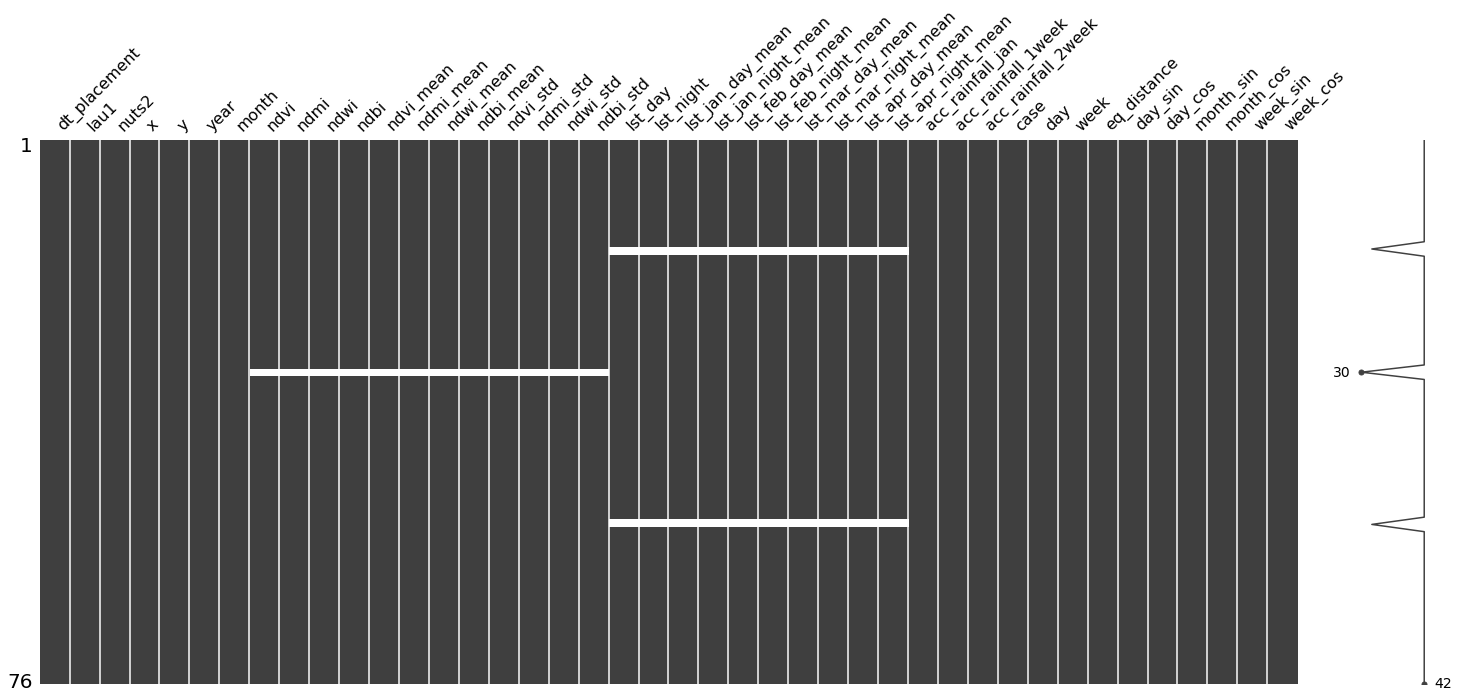

In [28]:
missingno.matrix(dataset)

In [29]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [30]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [31]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [32]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [33]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αλεξανδρειας,478.8,86.8,38293.0
1,αλμωπιας,985.8,28.0,24924.0
2,αμπελοκηπων μενεμενης,9.8,5319.1,49674.0
3,αμφιπολης,411.8,22.3,7169.0
4,αριστοτελη,747.0,24.5,16994.0
...,...,...,...,...
33,σιθωνιας,516.8,24.0,11631.0
34,σιντικης,1103.4,20.1,18532.0
35,σκυδρας,239.5,84.3,18080.0
36,χαλκηδονος,391.5,86.0,29951.0


In [34]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['ναουσας']

Length: 1


In [35]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [36]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [37]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

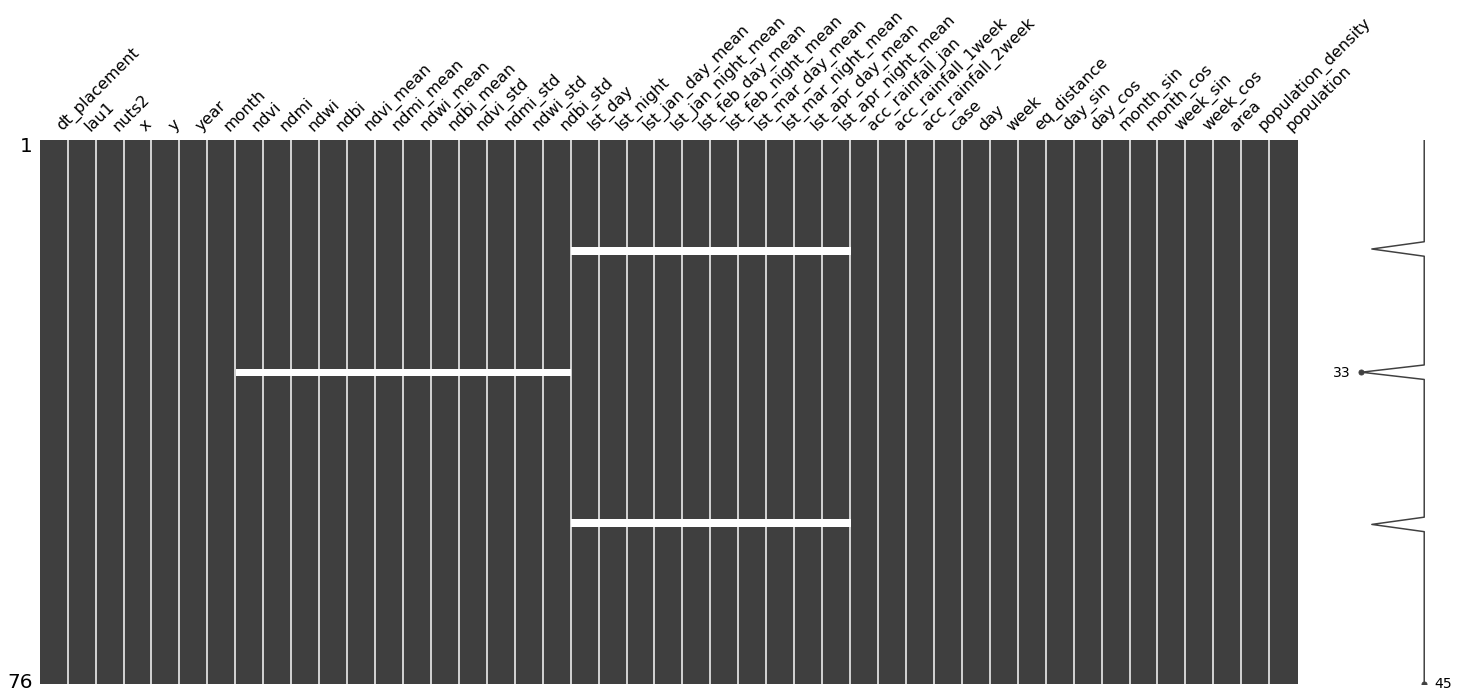

In [38]:
missingno.matrix(dataset)

In [39]:
missing = describe_dataframe(dataset)

In [40]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2023-05-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2023,5,0.170150,-0.100573,-0.212535,0.100573,0.180756,-0.089859,-0.216488,0.089859,0.056536,0.041263,0.047193,0.041263,15266.500000,14262.750000,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,54.796496,1.026141,4.464013,0,1,18,46.44911,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,478.8,86.8,38293.0
1,2023-05-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2023,5,0.522353,0.123491,-0.447140,-0.123491,0.529450,0.124210,-0.459599,-0.124210,0.054125,0.054755,0.030793,0.054755,14510.727273,13972.181818,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,172.360332,7.549537,31.277387,0,1,18,46.48134,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,985.8,28.0,24924.0
2,2023-05-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2023,5,0.157606,0.030411,-0.169270,-0.030411,0.198656,0.031271,-0.205202,-0.031271,0.092685,0.059763,0.069722,0.059763,15051.000000,14251.000000,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,129.586469,8.539829,24.316921,0,1,18,46.65786,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,9.8,5319.1,49674.0
3,2023-05-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2023,5,0.301201,0.177338,-0.259019,-0.177338,0.378091,0.212700,-0.314783,-0.212700,0.060114,0.092679,0.062196,0.092679,14701.250000,14108.500000,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,73.469888,12.292893,36.676132,0,1,18,47.42581,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,411.8,22.3,7169.0
4,2023-05-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2023,5,0.626137,0.251029,-0.497413,-0.251029,0.615676,0.248771,-0.488425,-0.248771,0.060201,0.055246,0.041223,0.055246,14574.250000,14108.125000,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,161.783456,13.509865,88.392827,0,1,18,46.91682,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,747.0,24.5,16994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,2023-05-16,σιθωνιας,κεντρικης μακεδονιας,23.82811,40.11026,2023,5,0.460100,0.185161,-0.359489,-0.185161,0.458051,0.179094,-0.360377,-0.179094,0.047389,0.048060,0.026991,0.048060,14881.200000,14261.000000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,297.676055,7.359427,52.826785,0,16,20,46.65417,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,516.8,24.0,11631.0
72,2023-05-16,σιντικης,κεντρικης μακεδονιας,23.38806,41.31348,2023,5,0.518181,0.131836,-0.439619,-0.131836,0.486416,0.145806,-0.409787,-0.145806,0.054154,0.056396,0.037679,0.056396,14843.636364,14090.909091,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,127.338997,5.800902,32.885985,0,16,20,47.47426,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,1103.4,20.1,18532.0
73,2023-05-16,σκυδρας,κεντρικης μακεδονιας,22.14670,40.82294,2023,5,0.628047,0.212817,-0.529299,-0.212817,0.638043,0.233769,-0.531265,-0.233769,0.047432,0.038162,0.026900,0.038162,14985.500000,14272.000000,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,160.319209,4.455468,74.351227

In [41]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-May.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,22.483978,40.644680,2023-05-01,229
1,21.940791,40.977027,2023-05-01,135
2,22.891980,40.656030,2023-05-01,65
3,23.982527,40.915103,2023-05-01,48
4,23.691080,40.495934,2023-05-01,42
...,...,...,...,...
71,23.828106,40.110264,2023-05-16,51
72,23.388058,41.313484,2023-05-16,52
73,22.146700,40.822940,2023-05-16,60
74,22.723020,40.753567,2023-05-16,44


In [42]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [43]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [44]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0011119492658909769


In [45]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [46]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [47]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [48]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2023-05-01,αλεξανδρειας,κεντρικης μακεδονιας,22.48398,40.64468,2023,5,0.170150,-0.100573,-0.212535,0.100573,0.180756,-0.089859,-0.216488,0.089859,0.056536,0.041263,0.047193,0.041263,15266.500000,14262.750000,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,54.796496,1.026141,4.464013,0,1,18,46.44911,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,478.8,86.8,38293.0,229
1,2023-05-01,αλμωπιας,κεντρικης μακεδονιας,21.94079,40.97703,2023,5,0.522353,0.123491,-0.447140,-0.123491,0.529450,0.124210,-0.459599,-0.124210,0.054125,0.054755,0.030793,0.054755,14510.727273,13972.181818,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,172.360332,7.549537,31.277387,0,1,18,46.48134,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,985.8,28.0,24924.0,135
2,2023-05-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2023,5,0.157606,0.030411,-0.169270,-0.030411,0.198656,0.031271,-0.205202,-0.031271,0.092685,0.059763,0.069722,0.059763,15051.000000,14251.000000,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,129.586469,8.539829,24.316921,0,1,18,46.65786,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,9.8,5319.1,49674.0,65
3,2023-05-01,αμφιπολης,κεντρικης μακεδονιας,23.98253,40.91510,2023,5,0.301201,0.177338,-0.259019,-0.177338,0.378091,0.212700,-0.314783,-0.212700,0.060114,0.092679,0.062196,0.092679,14701.250000,14108.500000,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,73.469888,12.292893,36.676132,0,1,18,47.42581,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,411.8,22.3,7169.0,48
4,2023-05-01,αριστοτελη,κεντρικης μακεδονιας,23.69108,40.49593,2023,5,0.626137,0.251029,-0.497413,-0.251029,0.615676,0.248771,-0.488425,-0.248771,0.060201,0.055246,0.041223,0.055246,14574.250000,14108.125000,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,161.783456,13.509865,88.392827,0,1,18,46.91682,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,747.0,24.5,16994.0,42


<AxesSubplot:>

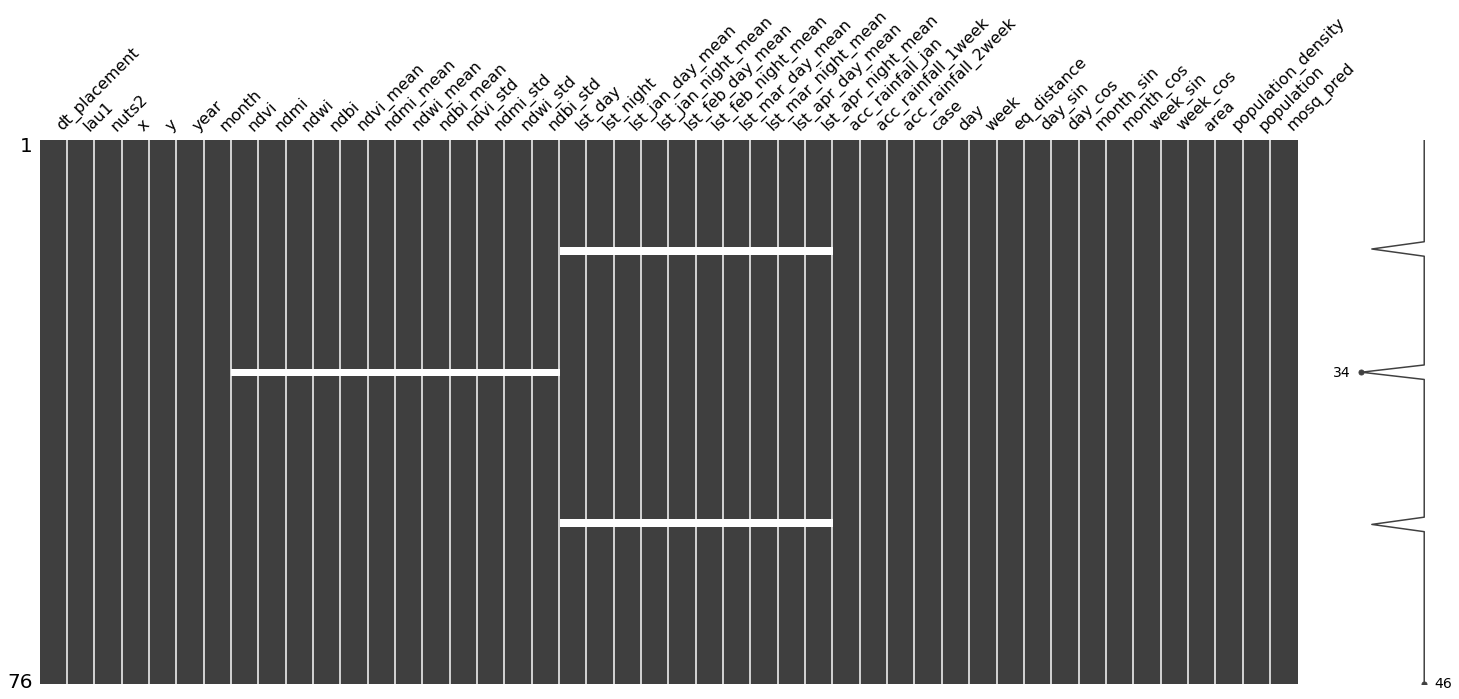

In [49]:
missingno.matrix(dataset)

In [50]:
dataset.reset_index(inplace=True, drop=True)

In [51]:
dataset = calculate_mosq_previous(dataset)

In [52]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

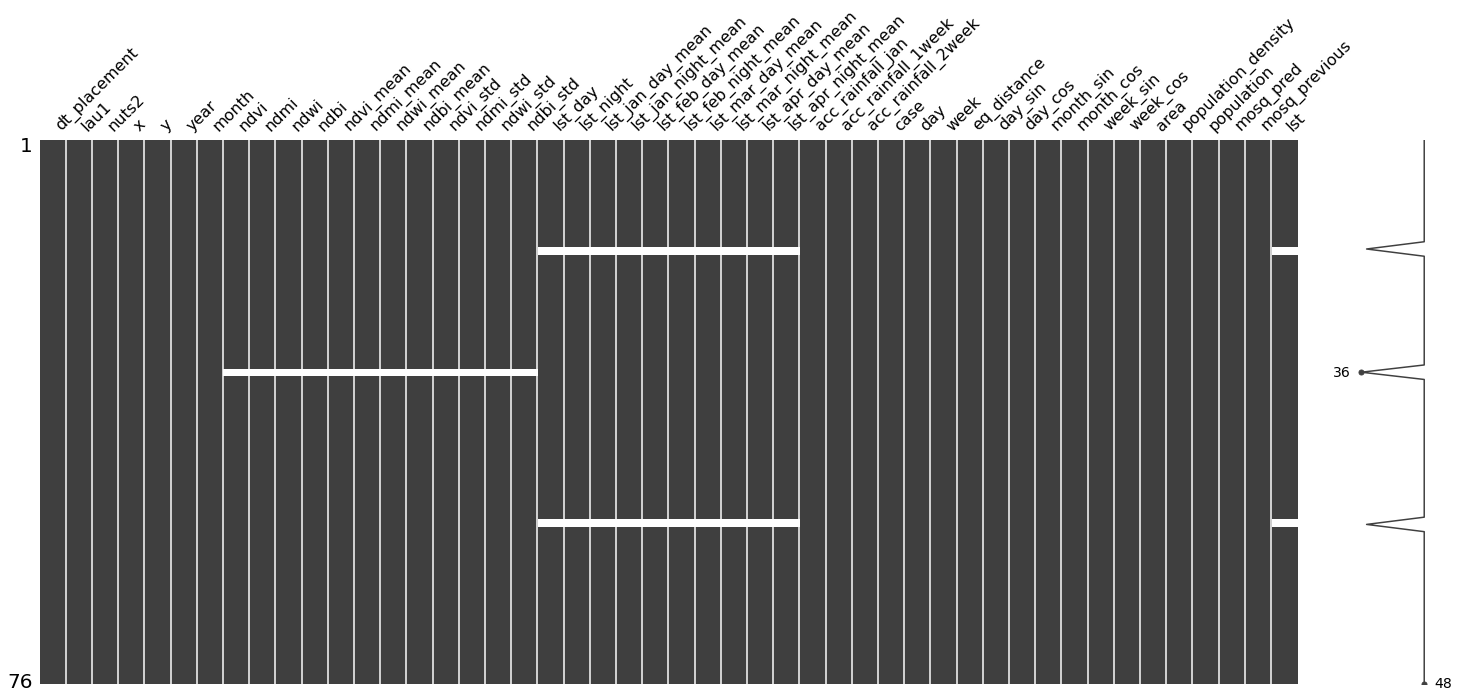

In [53]:
missingno.matrix(dataset)

In [54]:
dataset['case'].value_counts()

0    76
Name: case, dtype: int64

In [55]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [56]:
dataset = convert_multiple_cases(dataset)

In [57]:
dataset['case'].value_counts()

0    76
Name: case, dtype: int64

In [58]:
cols = dataset.columns

In [59]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'area', 'population_density',
       'population', 'mosq_pred', 'mosq_previous', 'lst'],
      dtype='object')

In [60]:
len(cols)

48

In [61]:
# check columns

In [62]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [63]:
len(final_columns)

48

In [64]:
dataset_final = dataset[final_columns].copy()

In [65]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2023-05-01,κεντρικης μακεδονιας,αλεξανδρειας,1,5,18,2023,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,478.8,38293.0,86.8,46.44911,0.170150,-0.100573,-0.212535,0.100573,0.180756,-0.089859,-0.216488,0.089859,0.056536,0.041263,0.047193,0.041263,22.142500,32.180000,12.105000,11.533780,1.843800,12.127693,0.466225,22.192221,5.309037,25.273970,7.897753,1.026141,4.464013,54.796496,229,0,0
1,21.94079,40.97703,2023-05-01,κεντρικης μακεδονιας,αλμωπιας,1,5,18,2023,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,985.8,24924.0,28.0,46.48134,0.522353,0.123491,-0.447140,-0.123491,0.529450,0.124210,-0.459599,-0.124210,0.054125,0.054755,0.030793,0.054755,11.679091,17.064545,6.293636,8.005546,2.551910,7.831732,0.138556,13.334987,3.903208,14.773962,5.972576,7.549537,31.277387,172.360332,135,0,0
2,22.89198,40.65603,2023-05-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,5,18,2023,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,9.8,49674.0,5319.1,46.65786,0.157606,0.030411,-0.169270,-0.030411,0.198656,0.031271,-0.205202,-0.031271,0.092685,0.059763,0.069722,0.059763,19.870000,27.870000,11.870000,12.381429,3.596667,11.870000,2.525385,18.760769,5.121429,23.898000,11.870000,8.539829,24.316921,129.586469,65,0,0
3,23.98253,40.91510,2023-05-01,κεντρικης μακεδονιας,αμφιπολης,1,5,18,2023,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,411.8,7169.0,22.3,47.42581,0.301201,0.177338,-0.259019,-0.177338,0.378091,0.212700,-0.314783,-0.212700,0.060114,0.092679,0.062196,0.092679,14.947500,20.875000,9.020000,10.229485,3.130833,8.615636,0.482557,15.199095,4.675023,19.470028,6.606750,12.292893,36.676132,73.469888,48,0,0
4,23.69108,40.49593,2023-05-01,κεντρικης μακεδονιας,αριστοτελη,1,5,18,2023,0.201299,0.979530,0.5,-0.866025,0.845596,-0.533823,747.0,16994.0,24.5,46.91682,0.626137,0.251029,-0.497413,-0.251029,0.615676,0.248771,-0.488425,-0.248771,0.060201,0.055246,0.041223,0.055246,13.673750,18.335000,9.012500,10.678026,3.098890,9.360022,1.950259,15.351957,4.242043,17.012319,6.938982,13.509865,88.392827,161.783456,42,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,23.82811,40.11026,2023-05-16,κεντρικης μακεδονιας,σιθωνιας,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,516.8,11631.0,24.0,46.65417,0.460100,0.185161,-0.359489,-0.185161,0.458051,0.179094,-0.360377,-0.179094,0.047389,0.048060,0.026991,0.048060,18.272000,24.474000,12.070000,12.848600,5.412383,10.233594,3.269092,15.381572,5.621769,18.744510,8.323627,7.359427,52.826785,297.676055,48,48,0
72,23.38806,41.31348,2023-05-16,κεντρικης μακεδονιας,σιντικης,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,1103.4,18532.0,20.1,47.47426,0.518181,0.131836,-0.439619,-0.131836,0.486416,0.145806,-0.409787,-0.145806,0.054154,0.056396,0.037679,0.056396,16.195455,23.722727,8.668182,10.684245,2.099928,8.360350,-0.138722,15.182432,3.623271,17.447298,5.724123,5.800902,32.885985,127.338997,62,62,0
73,22.14670,40.82294,2023-05-16,κεντρικης μακεδονιας,σκυδρας,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,239.5,18080.0,84.3,46.44339,0.628047,0.212817,-0.529299,-0.212817,0.638043,0.233769,-0.531265,-0.233769,0.047432,0.038162,0.026900,0.038162,19.425000,26.560000,12.290000,11.476154,2.522000,12.264130,0.402625,18.565879,5.441556,20.967750,9.518667,4.455468,74.351227,160.319209,70,70,0
74,22.72302,40.75357,202

In [66]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-May.csv", encoding = enc, index = False)